In [2]:
# SQL Engine
import sqlalchemy as sa

db_path = r"C:\Users\rober\Documents\Python\work_examples\python\portfolio_project\data\bitcoin_gold_database.db"
engine = sa.create_engine(f'sqlite:///{db_path}')

inspector = sa.inspect(engine)
print(f"Tables found: {inspector.get_table_names()}")

Tables found: ['macro_data', 'market_data_filled', 'market_data_sycned']


In [16]:
columns = inspector.get_columns('market_data_filled')
columns

[{'name': 'Date',
  'type': TEXT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'BTC',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'DXY',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'Gold',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'SP500',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'Yield_10Y',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'VIX',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'BTC_norm',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'DXY_norm',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'Gold_norm',
  'type': FLOAT(),
  'nullable': True,
  'default': None,
  'primary_key': 0},
 {'name': 'SP50

In [17]:
import pandas as pd

query = """
SELECT 
    Date,  
    SP500,
    SP500_norm,
    BTC, 
    BTC_norm,
    Gold, 
    Gold_norm
FROM market_data_filled
WHERE SP500 IS NOT NULL
ORDER BY Date ASC
"""

df = pd.read_sql(query, engine)
df['Date'] = pd.to_datetime(df['Date'])
df.head() 

,Date,SP500,SP500_norm,BTC,BTC_norm,Gold,Gold_norm
0,2016-01-01,2012.660034,100.000000,434.334015,100.000000,1075.099976,100.000000
1,2016-01-02,2012.660034,100.000000,433.437988,99.793701,1075.099976,100.000000
2,2016-01-03,2012.660034,100.000000,430.010986,99.004676,1075.099976,100.000000
3,2016-01-04,2012.660034,100.000000,433.091003,99.713812,1075.099976,100.000000
4,2016-01-05,2016.709961,100.201223,431.959991,99.453411,1078.400024,100.306953


In [18]:
print(df.describe())

                                Date        SP500   SP500_norm            BTC  \
count                           3652  3652.000000  3652.000000    3652.000000   
mean   2020-12-30 12:00:00.000000256  3770.123121   187.320415   30256.581787   
min              2016-01-01 00:00:00  1829.079956    90.878734     364.330994   
25%              2018-07-01 18:00:00  2711.667480   134.730527    6415.053711   
50%              2020-12-30 12:00:00  3674.840088   182.586230   17129.605469   
75%              2023-07-01 06:00:00  4514.269897   224.293712   46446.924805   
max              2025-12-30 00:00:00  6932.049805   344.422291  124752.531250   
std                              NaN  1292.049813    64.196128   32057.185621   

           BTC_norm         Gold    Gold_norm  
count   3652.000000  3652.000000  3652.000000  
mean    6966.201299  1830.436718   170.257349  
min       83.882676  1073.900024    99.888387  
25%     1476.986257  1298.549957   120.784112  
50%     3943.878416  1757.3499

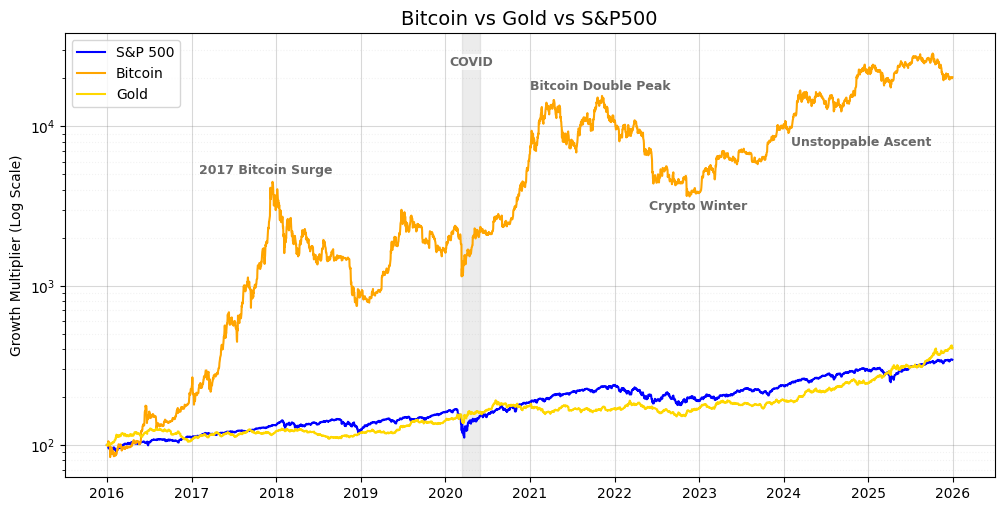

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(12, 6))
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

# Using Normalized columns created using Base-100
plt.plot(df['Date'], df['SP500_norm'], label='S&P 500', color='blue')
plt.plot(df['Date'], df['BTC_norm'], label='Bitcoin', color='orange') 
plt.plot(df['Date'], df['Gold_norm'], label='Gold', color='gold')

# Using Log Scale
plt.yscale('log')

# Titles and Labels
plt.title('Bitcoin vs Gold vs S&P500', fontsize=14)
plt.ylabel('Growth Multiplier (Log Scale)')
plt.grid(True, which="major", color='gray', linestyle='-', alpha=0.3)
plt.grid(True, which="minor", color='gray', linestyle=':', alpha=0.1)

### Annotations ###

# Bitcoin Surge
plt.annotate('2017 Bitcoin Surge', 
             xy=(pd.Timestamp('2017-12-17'), 25000), 
             xytext=(pd.Timestamp('2017-02-01'), 5000), 
             fontsize=9, 
             color='dimgray',
             fontweight='bold')

# COVID 
start_date = pd.Timestamp('2020-03-12')
end_date = pd.Timestamp('2020-06-01')

plt.axvspan(start_date, end_date, color='gray', alpha=0.15)
mid_date = start_date + (end_date - start_date) / 2

plt.text(mid_date, 0.95, "COVID", 
         transform=plt.gca().get_xaxis_transform(), 
         ha='center', va='top', 
         color='dimgray', fontsize=9, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Bitcoin Double Peak 
plt.annotate('Bitcoin Double Peak', 
             xy=(pd.Timestamp('2021-01-01'), 5000), 
             xytext=(pd.Timestamp('2021-01-01'), 17000), 
             fontsize=9, 
             color='dimgray',
             fontweight='bold')

# Crypto Winter 
plt.annotate('Crypto Winter', 
             xy=(pd.Timestamp('2022-06-01'), 5000), 
             xytext=(pd.Timestamp('2022-06-01'), 3000), 
             fontsize=9, 
             color='dimgray',
             fontweight='bold')

# Unstoppable Ascent  
plt.annotate('Unstoppable Ascent', 
             xy=(pd.Timestamp('2024-02-01'), 5000), 
             xytext=(pd.Timestamp('2024-02-01'), 7500), 
             fontsize=9, 
             color='dimgray',
             fontweight='bold')

plt.subplots_adjust(top=0.85)
plt.legend()
plt.show()

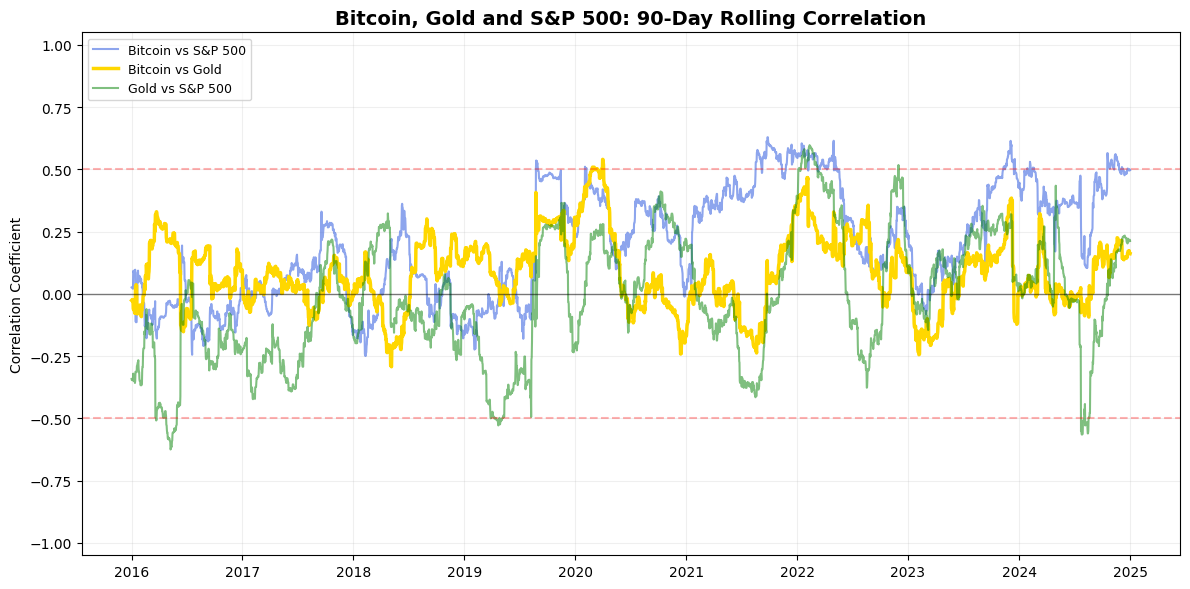

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate Correlations (Keeping your original logic)
df['BTC_Ret'] = np.log(df['BTC'] / df['BTC'].shift(1))
df['SP500_Ret'] = np.log(df['SP500'] / df['SP500'].shift(1))
df['Gold_Ret'] = np.log(df['Gold'] / df['Gold'].shift(1))

corr_btc_sp = df['BTC_Ret'].rolling(90).corr(df['SP500_Ret']).dropna()
corr_btc_gold = df['BTC_Ret'].rolling(90).corr(df['Gold_Ret']).dropna()
corr_gold_sp = df['Gold_Ret'].rolling(90).corr(df['SP500_Ret']).dropna()

# 2. Integration: The "Manual Ruler" Plotting
plt.figure(figsize=(12, 6))

# Plotting by stripping the index (.values) to prevent the 1970 reset
plt.plot(corr_btc_sp.values, color='royalblue', lw=1.5, alpha=0.6, label='Bitcoin vs S&P 500')
plt.plot(corr_btc_gold.values, color='gold', lw=2.5, label='Bitcoin vs Gold')
plt.plot(corr_gold_sp.values, color='green', lw=1.5, alpha=0.5, label='Gold vs S&P 500')

# 3. Create Manual Labels (Calculating placement based on data length)
num_points = len(corr_btc_sp)
# We find indices at regular intervals to represent years
tick_spots = np.linspace(0, num_points - 1, 10).astype(int) 
tick_labels = ["2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# Force the labels onto the graph
plt.xticks(tick_spots, tick_labels)

# 4. Thresholds and Style (Your original styling)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3)
plt.axhline(-0.5, color='red', linestyle='--', alpha=0.3)
plt.axhline(0, color='black', lw=1, alpha=0.5)

plt.title('Bitcoin, Gold and S&P 500: 90-Day Rolling Correlation', fontweight='bold', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.ylim(-1.05, 1.05)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Create Results Dictionary
summary_stats = {
    "Asset Pair": ["BTC vs S&P 500", "BTC vs Gold", "Gold vs S&P 500"],
    "Mean Correlation": [
        corr_btc_sp.mean(), 
        corr_btc_gold.mean(), 
        corr_gold_sp.mean()
    ],
    "Max Correlation": [
        corr_btc_sp.max(), 
        corr_btc_gold.max(), 
        corr_gold_sp.max()
    ],
    "Days > 0.5 (%)": [
        (corr_btc_sp > 0.5).mean() * 100,
        (corr_btc_gold > 0.5).mean() * 100,
        (corr_gold_sp > 0.5).mean() * 100
    ],
    "Days < -0.5 (%)": [
        (corr_btc_sp < -0.5).mean() * 100,
        (corr_btc_gold < -0.5).mean() * 100,
        (corr_gold_sp < -0.5).mean() * 100
    ]
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary_stats)
print("--- 2016-2025 Correlation Summary ---")
print(summary_df.to_string(index=False))

--- 2016-2025 Correlation Summary ---
     Asset Pair  Mean Correlation  Max Correlation  Days > 0.5 (%)  Days < -0.5 (%)
 BTC vs S&P 500          0.203198         0.629007       10.471645         0.000000
    BTC vs Gold          0.084629         0.539932        0.505334         0.000000
Gold vs S&P 500         -0.019477         0.596958        1.880966         2.470522


In [24]:
# Find dates where S&P 500 crashed but Gold rose 
hedge_days = df[(df['SP500_Ret'] < -0.02) & (df['Gold_Ret'] > 0.01)]

print("On days where Gold acted as a hedge, what did Bitcoin do?")
print(hedge_days[['BTC_Ret', 'Gold_Ret', 'SP500_Ret']].describe())

On days where Gold acted as a hedge, what did Bitcoin do?
         BTC_Ret   Gold_Ret  SP500_Ret
count  23.000000  23.000000  23.000000
mean   -0.001167   0.020989  -0.029376
std     0.065904   0.011685   0.008638
min    -0.166434   0.010848  -0.060753
25%    -0.035547   0.013712  -0.033570
50%     0.004351   0.016256  -0.028510
75%     0.035345   0.028696  -0.023256
max     0.114079   0.054422  -0.020788
